# Desafío - Modelos de ensamble (Parte II)

Este notebook desarrolla el desafío de detección de cardiopatía usando modelos de ensamble secuencial.

Modelos utilizados:

1. AdaBoost
2. Gradient Boosting
3. XGBoost

## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
pandas_version_warning = None
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    xgboost_error = e

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
RANDOM_STATE = 42

## 2. Carga de datos

La base viene separada en tres archivos: `processed.cleveland.data`, `processed.hungarian.data` y `processed.switzerland.data`.

In [2]:
# Nombres esperados según el material de apoyo
data_files = [
    "processed.cleveland.data",
    "processed.hungarian.data",
    "processed.switzerland.data"
]

feature_file = "feature_names.csv"
zip_file = "Apoyo Desafío - Modelos de ensamble (Parte II).zip"

# Compatibilidad con nombres de archivo con tilde normalizada distinto en algunos sistemas
possible_zips = [
    zip_file,
    "Apoyo Desafío - Modelos de ensamble (Parte II).zip",
    "/mnt/data/Apoyo Desafío - Modelos de ensamble (Parte II).zip"
]

if not all(os.path.exists(f) for f in data_files): # codigo que intenta descomprimir el zip de los archivos.
    for z in possible_zips:
        if os.path.exists(z):
            with zipfile.ZipFile(z, "r") as zip_ref:
                zip_ref.extractall(".")
            print(f"Archivos extraídos desde: {z}")
            break

if os.path.exists(feature_file):
    feature_names = pd.read_csv(feature_file, header=None)[0].tolist()
else:
    feature_names = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
    ]

feature_names

['age',
 'sex',
 'cp',
 'threstbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

In [3]:
dfs = []
for file in data_files:
    df_temp = pd.read_csv(file, header=None, names=feature_names, na_values="?")
    df_temp["source"] = file
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
df.head()

,age,sex,cp,threstbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,0,processed.cleveland.data
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,2,processed.cleveland.data
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,1,processed.cleveland.data
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0,processed.cleveland.data
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,0,processed.cleveland.data


In [4]:
df.shape

(720, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        720 non-null    float64
 1   sex        720 non-null    float64
 2   cp         720 non-null    float64
 3   threstbps  717 non-null    float64
 4   chol       697 non-null    float64
 5   fbs        637 non-null    float64
 6   restecg    718 non-null    float64
 7   thalach    718 non-null    float64
 8   exang      718 non-null    float64
 9   oldpeak    714 non-null    float64
 10  slope      513 non-null    float64
 11  ca         307 non-null    float64
 12  thal       400 non-null    float64
 13  num        720 non-null    int64  
 14  source     720 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 84.5+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,720.0000,NaN,NaN,NaN,51.8889,9.1937,28.0000,45.0000,53.0000,58.0000,77.0000
sex,720.0000,NaN,NaN,NaN,0.7389,0.4395,0.0000,0.0000,1.0000,1.0000,1.0000
cp,720.0000,NaN,NaN,NaN,3.1792,0.9536,1.0000,2.0000,4.0000,4.0000,4.0000
threstbps,717.0000,NaN,NaN,NaN,131.8047,18.5293,80.0000,120.0000,130.0000,140.0000,200.0000
chol,697.0000,NaN,NaN,NaN,204.7747,109.2752,0.0000,182.0000,227.0000,270.0000,603.0000
fbs,637.0000,NaN,NaN,NaN,0.1099,0.3130,0.0000,0.0000,0.0000,0.0000,1.0000
restecg,718.0000,NaN,NaN,NaN,0.5682,0.8335,0.0000,0.0000,0.0000,1.0000,2.0000
thalach,718.0000,NaN,NaN,NaN,140.5655,25.6472,60.0000,122.0000,142.0000,160.0000,202.0000
exang,718.0000,NaN,NaN,NaN,0.3370,0.4730,0.0000,0.0000,0.0000,1.0000,1.0000
oldpeak,714.0000,NaN,NaN,NaN,0.7896,1.0670,-2.6000,0.0000,0.2000,1.5000,6.2000


## 3. Preparación inicial de la variable objetivo

La variable objetivo es `num`. Según el enunciado, debe quedar como binaria:

- `0`: sin cardiopatía
- `1`: con cardiopatía

In [7]:
df["num"] = np.where(df["num"] == 0, 0, 1)
df["num"].value_counts(dropna=False)

num
0    360
1    360
Name: count, dtype: int64

## 4. Revisión y tratamiento de valores ausentes

Criterio solicitado:

1. Si una variable tiene más de 25% de valores ausentes, se elimina.
2. Si tiene hasta 25% de valores ausentes, se imputa con el promedio según la clase `num`.
3. En variables categóricas, el promedio imputado se aproxima al entero más cercano.

In [8]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({
    "valores_ausentes": missing_count,
    "porcentaje_ausente": missing_pct
}).sort_values("porcentaje_ausente", ascending=False)
missing_table

,valores_ausentes,porcentaje_ausente
ca,413,57.3600
thal,320,44.4400
slope,207,28.7500
fbs,83,11.5300
chol,23,3.1900
oldpeak,6,0.8300
threstbps,3,0.4200
thalach,2,0.2800
exang,2,0.2800
restecg,2,0.2800


In [9]:
cols_to_drop = missing_table[missing_table["porcentaje_ausente"] > 25].index.tolist()

# source no es una variable clínica predictiva, se elimina para evitar que el modelo aprenda el origen del archivo
if "source" not in cols_to_drop:
    cols_to_drop.append("source")

cols_to_drop

['ca', 'thal', 'slope', 'source']

In [10]:
df_clean = df.drop(columns=cols_to_drop)

categorical_cols_original = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_cols = [col for col in categorical_cols_original if col in df_clean.columns]

for col in df_clean.columns:
    if col == "num":
        continue
    if df_clean[col].isna().sum() > 0:
        for target_value in [0, 1]:
            mask = (df_clean["num"] == target_value) & (df_clean[col].isna())
            mean_value = df_clean.loc[df_clean["num"] == target_value, col].mean()
            if col in categorical_cols:
                mean_value = round(mean_value)
            df_clean.loc[mask, col] = mean_value

df_clean.isna().sum()

age          0
sex          0
cp           0
threstbps    0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
num          0
dtype: int64

## 5. Variables dummies

Se construyen variables dummies para las variables discretas con tres o más categorías.

In [11]:
dummy_cols = []
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].nunique() >= 3:
        dummy_cols.append(col)

dummy_cols

['cp', 'restecg']

In [12]:
df_model = pd.get_dummies(df_clean, columns=dummy_cols, drop_first=True, dtype=int)
df_model.head()

,age,sex,threstbps,chol,fbs,thalach,exang,oldpeak,num,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0
0,63.0000,1.0000,145.0000,233.0000,1.0000,150.0000,0.0000,2.3000,0,0,0,0,0,1
1,67.0000,1.0000,160.0000,286.0000,0.0000,108.0000,1.0000,1.5000,1,0,0,1,0,1
2,67.0000,1.0000,120.0000,229.0000,0.0000,129.0000,1.0000,2.6000,1,0,0,1,0,1
3,37.0000,1.0000,130.0000,250.0000,0.0000,187.0000,0.0000,3.5000,0,0,1,0,0,0
4,41.0000,0.0000,130.0000,204.0000,0.0000,172.0000,0.0000,1.4000,0,1,0,0,0,1


In [13]:
df_model.shape

(720, 14)

## 6. Análisis exploratorio

Se revisa la distribución de la variable objetivo y de las variables clínicas. En clasificación médica, mirar solo `accuracy` puede ser engañoso si las clases están desbalanceadas; por eso después se usará también `precision`, `recall`, `f1-score` y curva ROC.

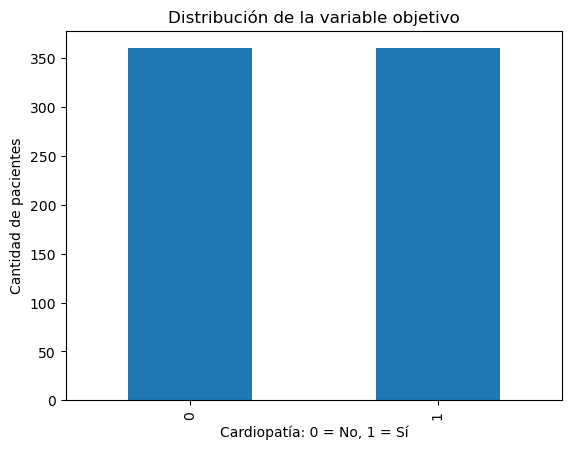

num
0   0.5000
1   0.5000
Name: proportion, dtype: float64

In [14]:
df_clean["num"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Cardiopatía: 0 = No, 1 = Sí")
plt.ylabel("Cantidad de pacientes")
plt.show()

df_clean["num"].value_counts(normalize=True).round(3)

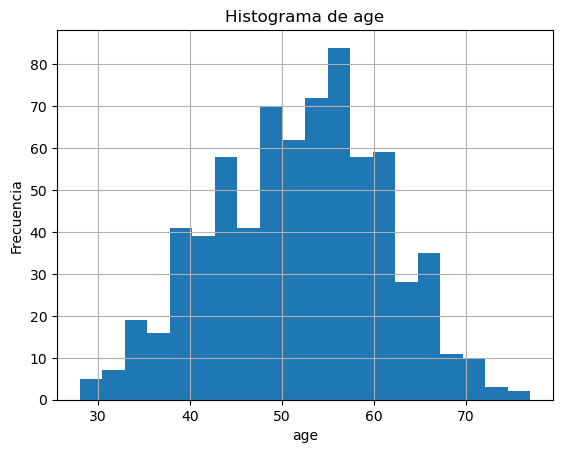

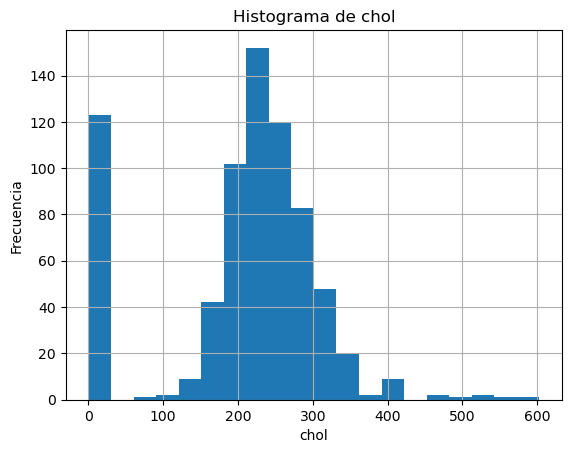

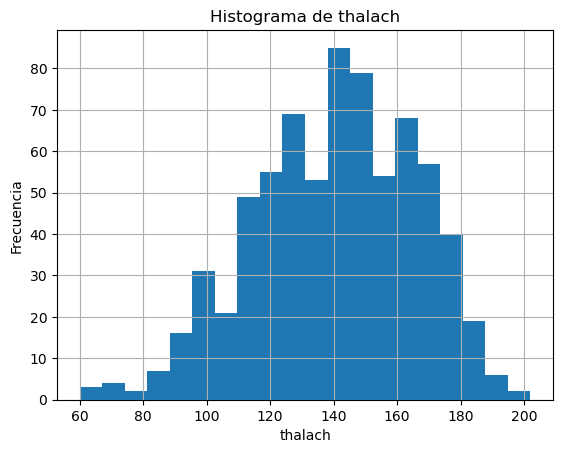

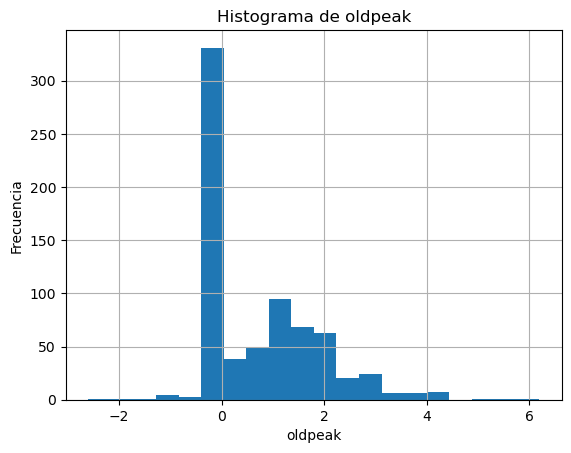

In [15]:
continuous_cols = [col for col in ["age", "trestbps", "chol", "thalach", "oldpeak"] if col in df_clean.columns]

for col in continuous_cols:
    df_clean[col].hist(bins=20)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

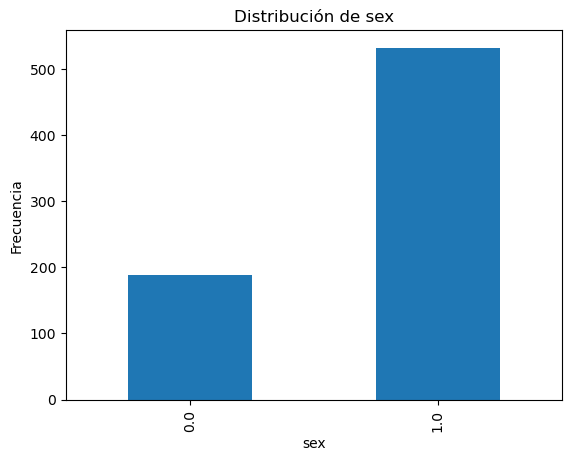

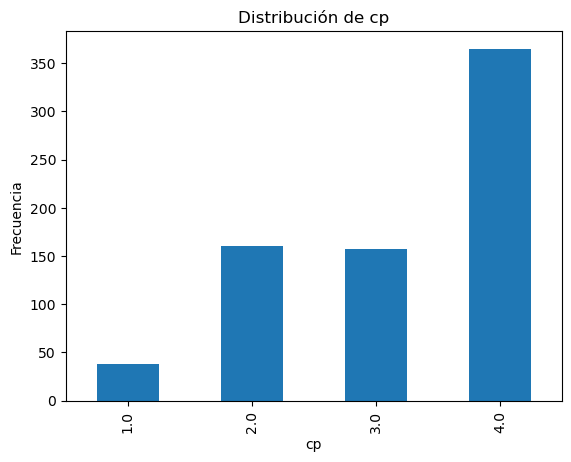

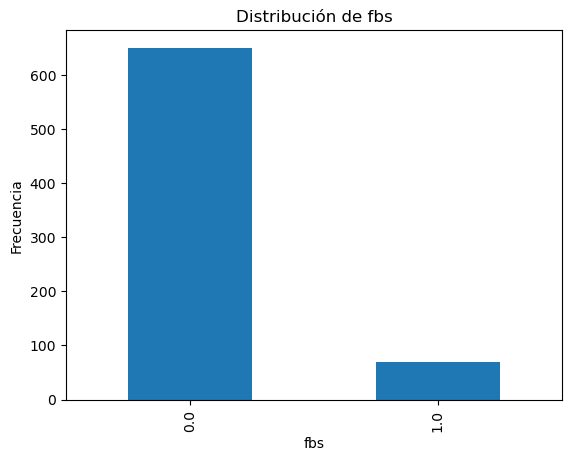

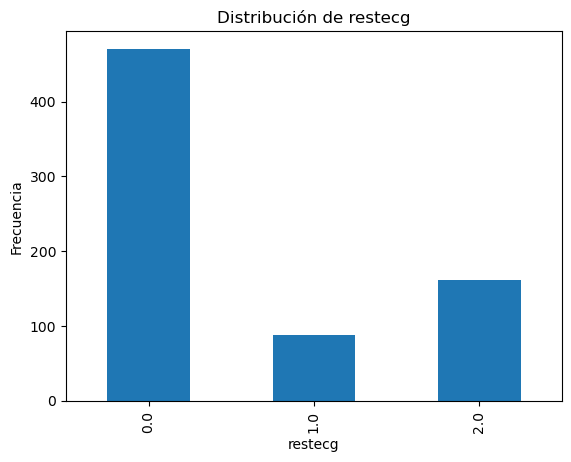

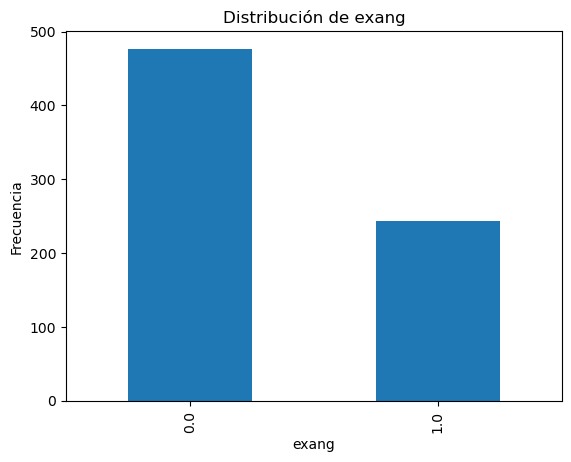

In [16]:
for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col].value_counts().sort_index().plot(kind="bar")
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.show()

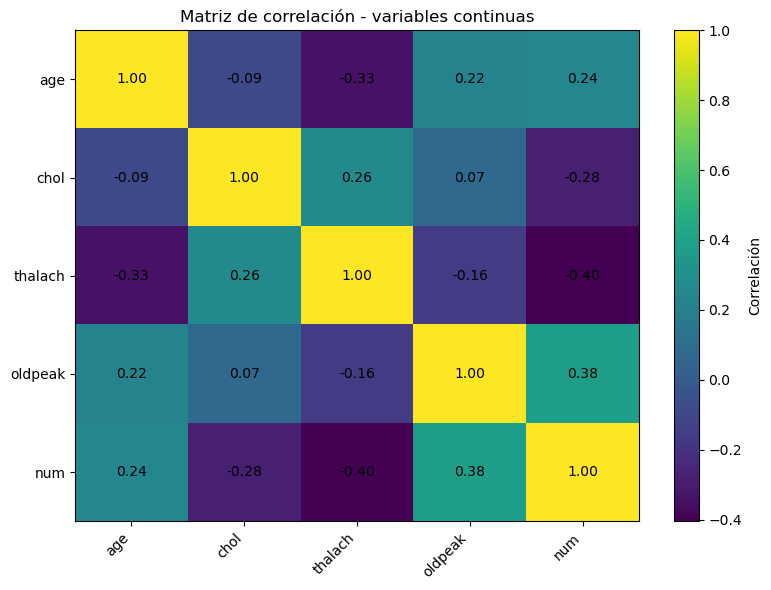

In [17]:
corr = df_clean[continuous_cols + ["num"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlación")
plt.title("Matriz de correlación - variables continuas")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

### Observaciones del análisis exploratorio

- La variable objetivo queda binaria, por lo tanto el problema corresponde a clasificación.
- Algunas variables tienen valores ausentes relevantes; se eliminan las que superan el 25% y el resto se imputa por promedio dentro de cada clase.
- Variables como edad, frecuencia cardiaca máxima y depresión ST (`oldpeak`) suelen aportar información útil para distinguir pacientes con y sin cardiopatía.
- Las variables categóricas con tres o más niveles fueron transformadas a dummies para que los modelos puedan interpretarlas correctamente.

## 7. División entrenamiento / test

Se separa 33% de los datos para test, usando estratificación para conservar la proporción de clases.

In [18]:
X = df_model.drop(columns="num")
y = df_model["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((482, 13), (238, 13), np.float64(0.5), np.float64(0.5))

## 8. Función de evaluación

Se crea una función para evaluar todos los modelos con las mismas métricas.

In [19]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    metrics = {
        "modelo": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score)
    }
    
    print(f"===== {model_name} =====")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))
    
    return metrics

## 9. Entrenamiento de modelos secuenciales con hiperparámetros por defecto

In [20]:
models = {
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        objective="binary:logistic"
    )
else:
    print("XGBoost no está disponible en este ambiente:", xgboost_error)

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    results.append(evaluate_model(model, X_test, y_test, name))

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
results_df

XGBoost no está disponible en este ambiente: No module named 'xgboost'
===== AdaBoost =====
Matriz de confusión:
[[98 21]
 [22 97]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       119
           1       0.82      0.82      0.82       119

    accuracy                           0.82       238
   macro avg       0.82      0.82      0.82       238
weighted avg       0.82      0.82      0.82       238

===== Gradient Boosting =====
Matriz de confusión:
[[91 28]
 [20 99]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       119
           1       0.78      0.83      0.80       119

    accuracy                           0.80       238
   macro avg       0.80      0.80      0.80       238
weighted avg       0.80      0.80      0.80       238



,modelo,accuracy,precision,recall,f1_score,roc_auc
0,AdaBoost,0.8193,0.8220,0.8151,0.8186,0.9070
1,Gradient Boosting,0.7983,0.7795,0.8319,0.8049,0.8771


### Comentario de desempeño inicial

El mejor modelo inicial se selecciona usando `f1-score`, porque esta métrica equilibra `precision` y `recall`. En un problema de salud, esto es más razonable que mirar solo `accuracy`, ya que interesa detectar correctamente los casos positivos sin inflar demasiado los falsos positivos.

## 10. Búsqueda de hiperparámetros

Se toma el modelo con mejor `f1-score` y se realiza búsqueda con grilla.

Grilla solicitada:

- `n_estimators`: 20 a 200 con 15 valores
- `learning_rate`: 0.004 a 1.0 con 40 valores
- `subsample`: 0.1 a 1.0 con 18 valores

Nota práctica: `subsample` existe en Gradient Boosting y XGBoost. Si el mejor modelo inicial fuera AdaBoost, se usa una grilla compatible con AdaBoost, porque AdaBoost de sklearn no tiene parámetro `subsample`.

In [21]:
best_initial_model_name = results_df.iloc[0]["modelo"]
best_initial_model_name

'AdaBoost'

In [22]:
n_estimators_grid = np.linspace(20, 200, 15, dtype=int)
learning_rate_grid = np.linspace(0.004, 1.0, 40)
subsample_grid = np.linspace(0.1, 1.0, 18)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

if best_initial_model_name == "AdaBoost":
    estimator = AdaBoostClassifier(random_state=RANDOM_STATE)
    param_grid = {
        "n_estimators": n_estimators_grid,
        "learning_rate": learning_rate_grid
    }
elif best_initial_model_name == "Gradient Boosting":
    estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_grid = {
        "n_estimators": n_estimators_grid,
        "learning_rate": learning_rate_grid,
        "subsample": subsample_grid
    }
else:
    estimator = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        objective="binary:logistic"
    )
    param_grid = {
        "n_estimators": n_estimators_grid,
        "learning_rate": learning_rate_grid,
        "subsample": subsample_grid
    }

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print("Mejor F1 promedio CV:", grid_search.best_score_)

Fitting 3 folds for each of 600 candidates, totalling 1800 fits
Mejores hiperparámetros:
{'learning_rate': np.float64(0.7956923076923077), 'n_estimators': np.int64(135)}
Mejor F1 promedio CV: 0.8337715454279871


In [23]:
best_tuned_model = grid_search.best_estimator_
tuned_metrics = evaluate_model(best_tuned_model, X_test, y_test, f"{best_initial_model_name} optimizado")

comparison_df = pd.concat([
    results_df,
    pd.DataFrame([tuned_metrics])
], ignore_index=True).sort_values("f1_score", ascending=False)

comparison_df

===== AdaBoost optimizado =====
Matriz de confusión:
[[100  19]
 [ 19 100]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       119
           1       0.84      0.84      0.84       119

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238



,modelo,accuracy,precision,recall,f1_score,roc_auc
2,AdaBoost optimizado,0.8403,0.8403,0.8403,0.8403,0.9069
0,AdaBoost,0.8193,0.8220,0.8151,0.8186,0.9070
1,Gradient Boosting,0.7983,0.7795,0.8319,0.8049,0.8771


## 11. Curvas ROC

Se comparan visualmente las curvas ROC de los modelos iniciales y del mejor modelo optimizado.

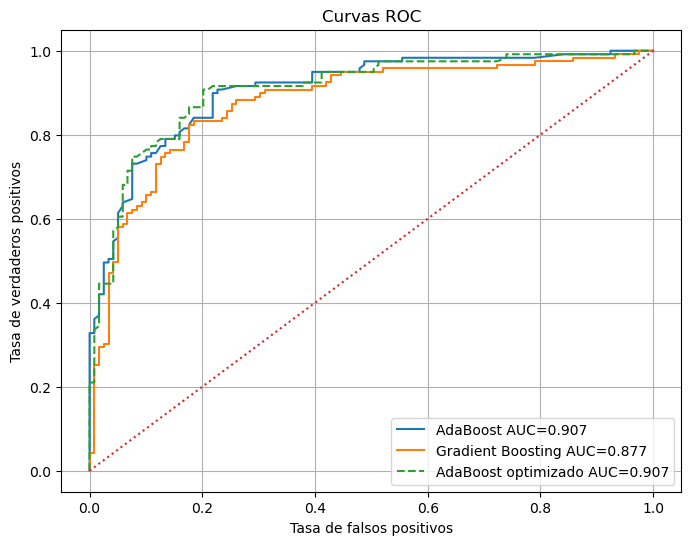

In [24]:
plt.figure(figsize=(8, 6))

for name, model in fitted_models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

y_score_tuned = best_tuned_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score_tuned)
auc = roc_auc_score(y_test, y_score_tuned)
plt.plot(fpr, tpr, linestyle="--", label=f"{best_initial_model_name} optimizado AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle=":")
plt.title("Curvas ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(True)
plt.show()

### Recomendación del modelo

Se recomienda elegir el modelo que combine mejor `f1-score` y `roc_auc`. Si el modelo optimizado mejora el `f1-score` respecto a los modelos base y mantiene una curva ROC superior o similar, es la mejor alternativa para este desafío.

En este contexto, no conviene elegir solo por `accuracy`, porque el costo de no detectar una cardiopatía puede ser alto. El `recall` también debe observarse con cuidado.

## 12. Importancia de variables

Se muestran las variables más importantes del mejor modelo luego de la búsqueda de hiperparámetros.

,variable,importancia
2,threstbps,0.2664
3,chol,0.2192
5,thalach,0.1748
0,age,0.0804
10,cp_4.0,0.0687
7,oldpeak,0.0663
6,exang,0.0410
1,sex,0.0406
8,cp_2.0,0.0186
12,restecg_2.0,0.0139


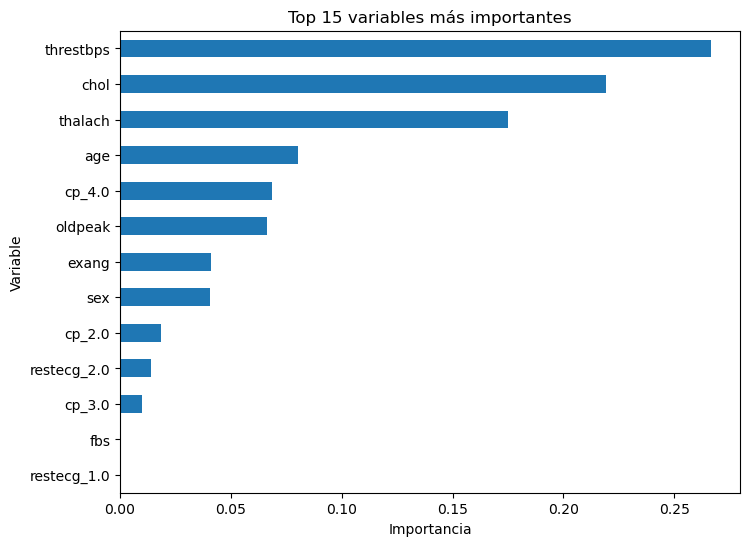

In [25]:
if hasattr(best_tuned_model, "feature_importances_"):
    importances = pd.DataFrame({
        "variable": X_train.columns,
        "importancia": best_tuned_model.feature_importances_
    }).sort_values("importancia", ascending=False)

    display(importances.head(15))

    importances.head(15).sort_values("importancia").plot(
        kind="barh",
        x="variable",
        y="importancia",
        legend=False,
        figsize=(8, 6)
    )
    plt.title("Top 15 variables más importantes")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.show()
else:
    print("El modelo seleccionado no posee atributo feature_importances_.")

### Comentario sobre importancia de variables

Las variables con mayor importancia son las que más aportan a separar pacientes con y sin cardiopatía dentro del modelo elegido. Estas variables no deben interpretarse automáticamente como causa médica directa; indican relevancia predictiva dentro de esta base de datos y bajo este procesamiento.

## 13. Conclusiones finales

- Se cargaron y unieron las tres bases clínicas en un único DataFrame.
- La variable `num` fue transformada a binaria según el criterio del enunciado.
- Se eliminaron variables con más de 25% de valores ausentes y el resto se imputó por promedio según clase.
- Se crearon variables dummies para variables discretas con tres o más categorías.
- Se entrenaron AdaBoost, Gradient Boosting y XGBoost con hiperparámetros por defecto.
- Se seleccionó el mejor modelo inicial con `f1-score`.
- Se aplicó búsqueda de hiperparámetros y se comparó el desempeño final.
- Se graficaron curvas ROC y se revisaron las variables más importantes del mejor modelo.